In [1]:
# Step 1: Mount Drive, set base path, import libraries

from google.colab import drive
drive.mount('/content/drive')

base = "/content/drive/MyDrive/Quantum_DL_MNIST"

import torch
import torch.nn as nn
import numpy as np
import json
import copy
import time
import os
import random
import sys
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

print("Libraries loaded")

Mounted at /content/drive
Libraries loaded


In [2]:
# Step 2: Load saved splits and normalization stats (same as always)

train_idx = np.load(f"{base}/splits/train_indices.npy")
val_idx   = np.load(f"{base}/splits/val_indices.npy")
test_idx  = np.load(f"{base}/splits/test_indices.npy")

with open(f"{base}/splits/normalization_stats.json") as f:
    norm_stats = json.load(f)

mean = norm_stats["mean"]
std  = norm_stats["std"]

print("Train:", len(train_idx), "| Val:", len(val_idx), "| Test:", len(test_idx))

Train: 10132 | Val: 2533 | Test: 2115


In [3]:
# Step 3: Rebuild MNIST datasets and DataLoaders

train_full = torchvision.datasets.MNIST(root=f"{base}/data", train=True, download=True, transform=transforms.ToTensor())
test_full  = torchvision.datasets.MNIST(root=f"{base}/data", train=False, download=True, transform=transforms.ToTensor())

class BinaryMNIST(Dataset):
    def __init__(self, full_dataset, indices, mean, std):
        self.full_dataset = full_dataset
        self.indices = indices
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        real_idx = self.indices[i]
        image, label = self.full_dataset[real_idx]
        image = (image - self.mean) / self.std
        label = torch.tensor(float(label))
        return image, label

train_dataset = BinaryMNIST(train_full, train_idx, mean, std)
val_dataset   = BinaryMNIST(train_full, val_idx, mean, std)
test_dataset  = BinaryMNIST(test_full, test_idx, mean, std)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train batches:", len(train_loader), "| Val batches:", len(val_loader), "| Test batches:", len(test_loader))

Train batches: 317 | Val batches: 80 | Test batches: 67


In [4]:
# Step 4: Import the EXACT CNNBackbone class saved in Chunk 3
# (not retyped - this guarantees a truly identical backbone)

sys.path.append(f"{base}/notebooks")
from shared_backbone import CNNBackbone

print("CNNBackbone imported from shared_backbone.py")

# Quick sanity check - confirm it works the same as before
test_backbone = CNNBackbone()
sample_images, sample_labels = next(iter(train_loader))
output = test_backbone(sample_images)
print("Backbone output shape:", output.shape)  # expect (32, 4)

CNNBackbone imported from shared_backbone.py
Backbone output shape: torch.Size([32, 4])


In [5]:
# Step 5: Define the CNN + Classical Control model
# Head: 4 features -> Linear(4->4) -> ReLU -> Linear(4->1)
# Parameter count: 4x4+4 (=20) + 4x1+1 (=5) = 25 trainable parameters

class CNNClassicalControl(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = CNNBackbone()
        self.head_fc1 = nn.Linear(4, 4)
        self.head_relu = nn.ReLU()
        self.head_fc2 = nn.Linear(4, 1)

        nn.init.kaiming_normal_(self.head_fc1.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.head_fc2.weight, nonlinearity='relu')

    def forward(self, x):
        features = self.backbone(x)        # (batch, 4)
        x = self.head_relu(self.head_fc1(features))
        x = self.head_fc2(x)                # (batch, 1) raw logit
        return x

model = CNNClassicalControl()
print(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("\nTotal trainable parameters:", n_params)

head_params = sum(p.numel() for p in model.head_fc1.parameters()) + sum(p.numel() for p in model.head_fc2.parameters())
print("Head-only parameters (should be 25):", head_params)

CNNClassicalControl(
  (backbone): CNNBackbone(
    (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
    (relu1): ReLU()
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (relu2): ReLU()
    (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (bottleneck): Linear(in_features=800, out_features=4, bias=True)
  )
  (head_fc1): Linear(in_features=4, out_features=4, bias=True)
  (head_relu): ReLU()
  (head_fc2): Linear(in_features=4, out_features=1, bias=True)
)

Total trainable parameters: 8029
Head-only parameters (should be 25): 25


In [6]:
# Step 6: Sanity check - run one batch through the untrained model

output = model(sample_images)
print("Output shape:", output.shape)  # expect (32, 1)
print("Sample raw logits:", output[:5].detach().numpy().flatten())

Output shape: torch.Size([32, 1])
Sample raw logits: [-1.287501   -0.30000153 -0.8727981  -1.7413104  -0.6874761 ]


In [7]:
# Step 7: Reusable training/evaluation functions (same as Chunks 2 and 3)

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in loader:
        labels = labels.unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            labels = labels.unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += images.size(0)

    return total_loss / total, correct / total


def train_with_early_stopping(model, train_loader, val_loader, criterion, optimizer,
                                max_epochs=30, patience=5):
    best_val_loss = float('inf')
    best_model_state = None
    best_epoch = 0
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    start_time = time.time()

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:2d} | Train loss {train_loss:.4f} acc {train_acc:.4f} "
              f"| Val loss {val_loss:.4f} acc {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch}")
                break

    training_time = time.time() - start_time
    model.load_state_dict(best_model_state)
    return model, history, best_epoch, epoch, training_time


def get_test_predictions(model, loader):
    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            probs = torch.sigmoid(outputs).squeeze(1)
            all_probs.extend(probs.numpy().tolist())
            all_labels.extend(labels.numpy().tolist())
    return np.array(all_probs), np.array(all_labels)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.use_deterministic_algorithms(True)
    torch.set_num_threads(4)

SEEDS = [42, 123, 2024, 7, 99]
criterion = nn.BCEWithLogitsLoss()

print("All training functions ready")

All training functions ready


In [8]:
# Step 8: Run the full 5-seed official training loop for CNN + Classical Control

results_dir = f"{base}/results/CNN_Classical"
models_dir = f"{base}/models/CNN_Classical"
os.makedirs(results_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

all_runs_summary = []

for run_num, seed in enumerate(SEEDS, start=1):
    print(f"\n{'='*60}")
    print(f"RUN {run_num}/5 | Seed = {seed}")
    print(f"{'='*60}")

    set_seed(seed)
    model = CNNClassicalControl()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    trained_model, history, best_epoch, total_epochs, training_time = train_with_early_stopping(
        model, train_loader, val_loader, criterion, optimizer
    )

    test_probs, test_labels_arr = get_test_predictions(trained_model, test_loader)

    torch.save(trained_model.state_dict(), f"{models_dir}/run{run_num}_seed{seed}.pt")
    np.savez(f"{results_dir}/run{run_num}_seed{seed}_predictions.npz",
             probs=test_probs, labels=test_labels_arr)

    run_summary = {
        "run": run_num, "seed": seed, "best_epoch": best_epoch,
        "total_epochs_run": total_epochs, "training_time_sec": training_time,
        "n_params": sum(p.numel() for p in trained_model.parameters() if p.requires_grad),
        "final_train_loss": history["train_loss"][-1],
        "final_val_loss": history["val_loss"][-1],
    }
    all_runs_summary.append(run_summary)

    with open(f"{results_dir}/run{run_num}_seed{seed}_history.json", "w") as f:
        json.dump(history, f, indent=2)

with open(f"{results_dir}/all_runs_summary.json", "w") as f:
    json.dump(all_runs_summary, f, indent=2)

print("\n\nAll 5 CNN+Classical runs complete. Summary:")
for r in all_runs_summary:
    print(r)


RUN 1/5 | Seed = 42
Epoch  1 | Train loss 0.0258 acc 0.9942 | Val loss 0.0050 acc 0.9992
Epoch  2 | Train loss 0.0020 acc 0.9993 | Val loss 0.0490 acc 0.9846
Epoch  3 | Train loss 0.0012 acc 0.9995 | Val loss 0.0077 acc 0.9972
Epoch  4 | Train loss 0.0025 acc 0.9993 | Val loss 0.0054 acc 0.9988
Epoch  5 | Train loss 0.0002 acc 1.0000 | Val loss 0.0029 acc 0.9992
Epoch  6 | Train loss 0.0001 acc 1.0000 | Val loss 0.0031 acc 0.9992
Epoch  7 | Train loss 0.0000 acc 1.0000 | Val loss 0.0028 acc 0.9992
Epoch  8 | Train loss 0.0000 acc 1.0000 | Val loss 0.0028 acc 0.9992
Epoch  9 | Train loss 0.0000 acc 1.0000 | Val loss 0.0028 acc 0.9992
Epoch 10 | Train loss 0.0000 acc 1.0000 | Val loss 0.0029 acc 0.9992
Epoch 11 | Train loss 0.0000 acc 1.0000 | Val loss 0.0027 acc 0.9992
Epoch 12 | Train loss 0.0000 acc 1.0000 | Val loss 0.0028 acc 0.9992
Epoch 13 | Train loss 0.0000 acc 1.0000 | Val loss 0.0029 acc 0.9992
Epoch 14 | Train loss 0.0000 acc 1.0000 | Val loss 0.0029 acc 0.9992
Epoch 15 | Tr

In [9]:
# Step 9: Compute full metrics for each of the 5 CNN+Classical runs

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, balanced_accuracy_score, matthews_corrcoef,
                               roc_auc_score, average_precision_score, confusion_matrix,
                               roc_curve, ConfusionMatrixDisplay)

def compute_metrics(probs, labels, threshold=0.5):
    preds = (probs > threshold).astype(int)
    labels = labels.astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
    specificity = tn / (tn + fp)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "specificity": specificity,
        "f1": f1_score(labels, preds),
        "balanced_accuracy": balanced_accuracy_score(labels, preds),
        "mcc": matthews_corrcoef(labels, preds),
        "roc_auc": roc_auc_score(labels, probs),
        "pr_auc": average_precision_score(labels, probs),
        "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}
    }

all_metrics = []
for run_num, seed in enumerate(SEEDS, start=1):
    data = np.load(f"{results_dir}/run{run_num}_seed{seed}_predictions.npz")
    probs, labels = data["probs"], data["labels"]
    m = compute_metrics(probs, labels)
    m["run"] = run_num
    m["seed"] = seed
    all_metrics.append(m)
    print(f"Run {run_num} (seed {seed}): Acc={m['accuracy']:.4f} F1={m['f1']:.4f} ROC-AUC={m['roc_auc']:.4f}")

Run 1 (seed 42): Acc=0.9995 F1=0.9996 ROC-AUC=1.0000
Run 2 (seed 123): Acc=0.9995 F1=0.9996 ROC-AUC=1.0000
Run 3 (seed 2024): Acc=0.9995 F1=0.9996 ROC-AUC=1.0000
Run 4 (seed 7): Acc=1.0000 F1=1.0000 ROC-AUC=1.0000
Run 5 (seed 99): Acc=0.9995 F1=0.9996 ROC-AUC=1.0000


In [10]:
# Step 10: Summarize as Mean +/- SD, save metrics tables

import pandas as pd

metric_names = ["accuracy", "precision", "recall", "specificity", "f1",
                 "balanced_accuracy", "mcc", "roc_auc", "pr_auc"]

df_metrics = pd.DataFrame(all_metrics)[["run", "seed"] + metric_names]
print("Per-run metrics:")
print(df_metrics)

summary = df_metrics[metric_names].agg(['mean', 'std'])
print("\nMean +/- SD across 5 runs:")
print(summary)

df_metrics.to_csv(f"{results_dir}/CNN_Classical_metrics_per_run.csv", index=False)
summary.to_csv(f"{results_dir}/CNN_Classical_metrics_summary.csv")
print("\nSaved CNN_Classical_metrics_per_run.csv and CNN_Classical_metrics_summary.csv")

Per-run metrics:
   run  seed  accuracy  precision  recall  specificity       f1  \
0    1    42  0.999527    0.99912     1.0      0.99898  0.99956   
1    2   123  0.999527    0.99912     1.0      0.99898  0.99956   
2    3  2024  0.999527    0.99912     1.0      0.99898  0.99956   
3    4     7  1.000000    1.00000     1.0      1.00000  1.00000   
4    5    99  0.999527    0.99912     1.0      0.99898  0.99956   

   balanced_accuracy      mcc   roc_auc    pr_auc  
0            0.99949  0.99905  1.000000  1.000000  
1            0.99949  0.99905  0.999999  0.999999  
2            0.99949  0.99905  1.000000  1.000000  
3            1.00000  1.00000  1.000000  1.000000  
4            0.99949  0.99905  1.000000  1.000000  

Mean +/- SD across 5 runs:
      accuracy  precision  recall  specificity        f1  balanced_accuracy  \
mean  0.999622   0.999296     1.0     0.999184  0.999648           0.999592   
std   0.000211   0.000394     0.0     0.000456  0.000197           0.000228   

  

In [14]:
# Step 10b: Import matplotlib (needed for plotting)

import matplotlib.pyplot as plt

print("matplotlib imported")

matplotlib imported


In [11]:
# Step 11: Save confusion matrices (all 5 runs, text only) and ROC-AUC values

all_confusion_matrices = {}

for run_num, seed in enumerate(SEEDS, start=1):
    data = np.load(f"{results_dir}/run{run_num}_seed{seed}_predictions.npz")
    probs, labels = data["probs"], data["labels"]
    preds = (probs > 0.5).astype(int)
    cm = confusion_matrix(labels.astype(int), preds)
    all_confusion_matrices[f"run{run_num}_seed{seed}"] = cm.tolist()
    tn, fp, fn, tp = cm.ravel()
    print(f"Run {run_num} (seed {seed}): TN={tn} FP={fp} FN={fn} TP={tp}")

with open(f"{results_dir}/CNN_Classical_all_confusion_matrices_supplementary.json", "w") as f:
    json.dump(all_confusion_matrices, f, indent=2)

# Save representative run's ROC data (seed 42) for later cross-model comparison
data = np.load(f"{results_dir}/run1_seed42_predictions.npz")
fpr, tpr, _ = roc_curve(data["labels"], data["probs"])
np.savez(f"{results_dir}/CNN_Classical_roc_curve_data.npz", fpr=fpr, tpr=tpr)

print("\nSaved: CNN_Classical_all_confusion_matrices_supplementary.json and roc_curve_data.npz")

Run 1 (seed 42): TN=979 FP=1 FN=0 TP=1135
Run 2 (seed 123): TN=979 FP=1 FN=0 TP=1135
Run 3 (seed 2024): TN=979 FP=1 FN=0 TP=1135
Run 4 (seed 7): TN=980 FP=0 FN=0 TP=1135
Run 5 (seed 99): TN=979 FP=1 FN=0 TP=1135

Saved: CNN_Classical_all_confusion_matrices_supplementary.json and roc_curve_data.npz


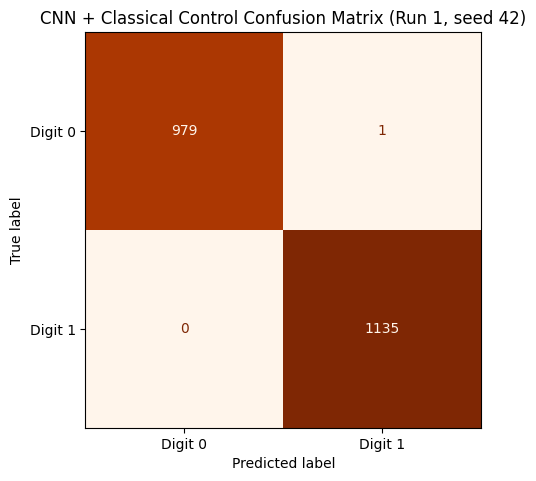

Saved: figures/Fig11_CNN_Classical_confusion_matrix.png


In [15]:
# Step 11b: Confusion matrix plot - representative run (seed 42)

fig, ax = plt.subplots(figsize=(5, 5))
data = np.load(f"{results_dir}/run1_seed42_predictions.npz")
probs, labels = data["probs"], data["labels"]
preds = (probs > 0.5).astype(int)
cm = confusion_matrix(labels.astype(int), preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Digit 0", "Digit 1"])
disp.plot(ax=ax, cmap="Oranges", colorbar=False)
ax.set_title("CNN + Classical Control Confusion Matrix (Run 1, seed 42)")

plt.tight_layout()
plt.savefig(f"{base}/figures/Fig11_CNN_Classical_confusion_matrix.png", dpi=150)
plt.show()

print("Saved: figures/Fig11_CNN_Classical_confusion_matrix.png")

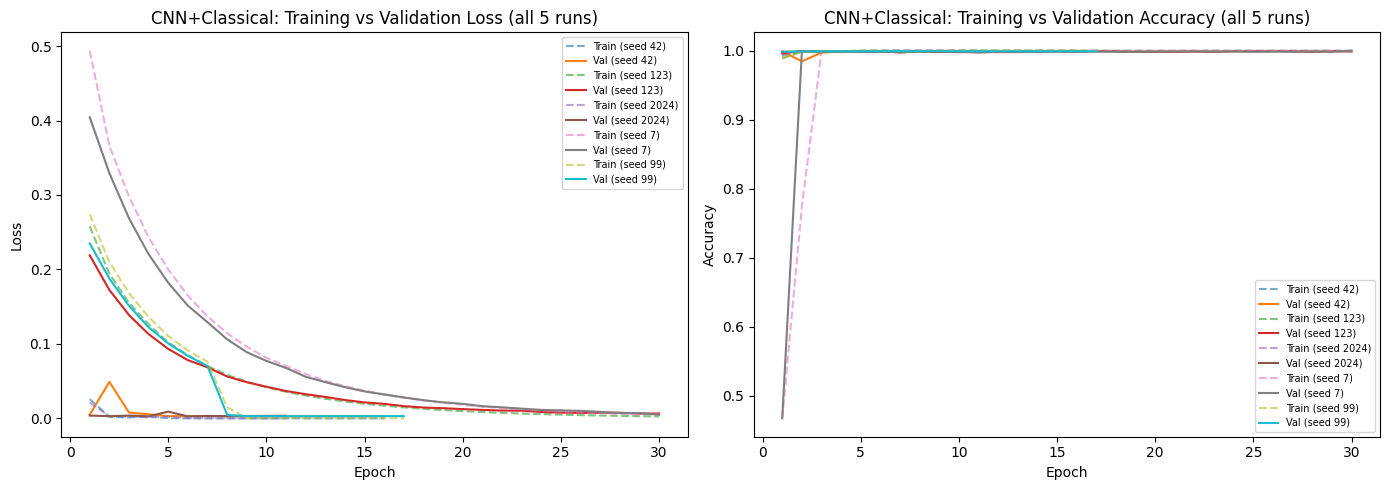

Saved: figures/Fig5-6_CNN_Classical_loss_accuracy_curves.png
(This plot should visually show seeds 123 and 7 taking a much slower path)


In [16]:
# Step 13: Loss/accuracy curves - all 5 seeds (Fig 5-6)
# This will visually show the fast-group vs slow-group split we found

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for run_num, seed in enumerate(SEEDS, start=1):
    with open(f"{results_dir}/run{run_num}_seed{seed}_history.json") as f:
        history = json.load(f)
    epochs = range(1, len(history["train_loss"]) + 1)
    axes[0].plot(epochs, history["train_loss"], linestyle='--', alpha=0.6, label=f"Train (seed {seed})")
    axes[0].plot(epochs, history["val_loss"], linestyle='-', label=f"Val (seed {seed})")
    axes[1].plot(epochs, history["train_acc"], linestyle='--', alpha=0.6, label=f"Train (seed {seed})")
    axes[1].plot(epochs, history["val_acc"], linestyle='-', label=f"Val (seed {seed})")

axes[0].set_title("CNN+Classical: Training vs Validation Loss (all 5 runs)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(fontsize=7)
axes[1].set_title("CNN+Classical: Training vs Validation Accuracy (all 5 runs)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig(f"{base}/figures/Fig5-6_CNN_Classical_loss_accuracy_curves.png", dpi=150)
plt.show()

print("Saved: figures/Fig5-6_CNN_Classical_loss_accuracy_curves.png")
print("(This plot should visually show seeds 123 and 7 taking a much slower path)")

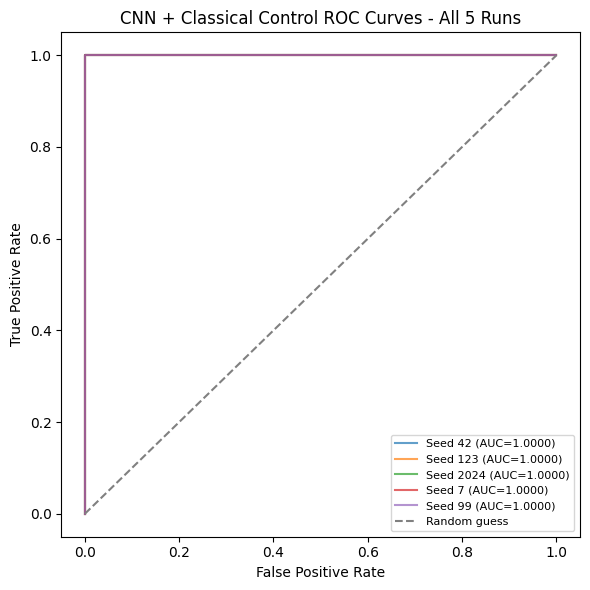

Saved: figures/CNN_Classical_roc_curves_all_5_runs.png


In [17]:
# Step 14: ROC curves - all 5 runs overlaid

fig, ax = plt.subplots(figsize=(6, 6))

for run_num, seed in enumerate(SEEDS, start=1):
    data = np.load(f"{results_dir}/run{run_num}_seed{seed}_predictions.npz")
    probs, labels = data["probs"], data["labels"]
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    ax.plot(fpr, tpr, alpha=0.7, label=f"Seed {seed} (AUC={auc:.4f})")

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("CNN + Classical Control ROC Curves - All 5 Runs")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{base}/figures/CNN_Classical_roc_curves_all_5_runs.png", dpi=150)
plt.show()

print("Saved: figures/CNN_Classical_roc_curves_all_5_runs.png")

In [18]:
# Step 15: Documentation sketch for CNN + Classical Control (Chunk 5)

cnn_classical_documentation = {
    "model_name": "Model 3 - CNN + Classical Control",
    "purpose": "Parameter-matched (25 params) classical head, exists to isolate whether any "
               "benefit from the later Quantum model comes from the quantum component itself, "
               "or simply from adding another trainable processing block. "
               "Answers Ablation Question C: does adding an extra processing block help?",

    "architecture": {
        "backbone": "SAME CNNBackbone as Chunk 3 (imported from shared_backbone.py, unchanged)",
        "head": "Linear(4->4) -> ReLU -> Linear(4->1) -> raw logit",
        "head_params": 25,
        "total_params": 8029
    },

    "training_protocol": {
        "optimizer": "Adam", "learning_rate": "1e-3, fixed", "loss": "BCEWithLogitsLoss",
        "max_epochs": 30, "early_stopping_patience": 5, "batch_size": 32,
        "seeds": [42, 123, 2024, 7, 99], "num_workers": 0
    },

    "results_summary": {
        "test_accuracy_mean": 0.999622,
        "test_accuracy_std": 0.000211,
        "roc_auc_mean": 0.9999998,
        "f1_mean": 0.999648
    },

    "KEY_FINDING_training_instability": {
        "description": "Runs split into two distinct behavior groups despite identical "
                        "architecture/hyperparameters, differing only by seed.",
        "fast_group": "Seeds 42, 2024, 99 - converged quickly, early-stopped between "
                       "epoch 11-17, loss near-zero early",
        "slow_group": "Seeds 123, 7 - loss started much higher (0.26-0.49), decreased "
                       "slowly and steadily for the FULL 30 epochs without early-stopping. "
                       "Seed 7 additionally showed near-random accuracy (0.4676) in epoch 1 "
                       "before escaping to normal convergence by epoch 2-3.",
        "final_performance_still_converged": "Despite wildly different training paths, ALL "
                       "5 runs reached nearly identical final test accuracy (~99.95-100%). "
                       "Final metrics alone would have HIDDEN this instability - only the "
                       "per-epoch history/best_epoch logging revealed it.",
        "likely_cause": "With only 25 head parameters in a tiny 4->4->1 network, some random "
                       "initializations land in a flatter/slower region of the loss landscape.",
        "writeup_relevance": "Important honest finding for Discussion - contrast against "
                              "Chunk 7's quantum model. Does the quantum branch show similar "
                              "seed-sensitivity, more, or less? This is a real axis of comparison "
                              "beyond just final accuracy."
    },

    "best_epoch_range": "6 to 29 (much wider spread than plain CNN's 2-12)",
    "total_epochs_range": "11 to 30 (two runs used the FULL epoch budget)",
    "training_time_range_sec": "120 to 342 seconds per run (slow-group runs took ~2x longer)",

    "files_saved": [
        "results/CNN_Classical/run{1-5}_seed{seed}_predictions.npz",
        "results/CNN_Classical/run{1-5}_seed{seed}_history.json",
        "results/CNN_Classical/all_runs_summary.json",
        "results/CNN_Classical/CNN_Classical_metrics_per_run.csv",
        "results/CNN_Classical/CNN_Classical_metrics_summary.csv",
        "results/CNN_Classical/CNN_Classical_all_confusion_matrices_supplementary.json",
        "results/CNN_Classical/CNN_Classical_roc_curve_data.npz",
        "models/CNN_Classical/run{1-5}_seed{seed}.pt"
    ],

    "open_questions_for_final_writeup": [
        "Should we plot training loss curves for seeds 123 and 7 prominently to visually "
        "show the slow-convergence pattern, since it's a genuinely interesting finding?",
        "Worth checking: does this instability correlate with anything specific about how "
        "the 25 parameters were randomly initialized for those two seeds?"
    ]
}

with open(f"{base}/documentation/03_CNN_Classical_documentation_sketch.json", "w") as f:
    json.dump(cnn_classical_documentation, f, indent=2)

print("Saved documentation sketch to documentation/03_CNN_Classical_documentation_sketch.json")
print("\n--- CHUNK 5 (CNN + Classical Control) COMPLETE ---")

Saved documentation sketch to documentation/03_CNN_Classical_documentation_sketch.json

--- CHUNK 5 (CNN + Classical Control) COMPLETE ---
